# Mini Google Lens

## Data Loading

In [19]:
#Extract the .tar file
import tarfile

tar_path = "./dataset/256_ObjectCategories.tar"
extract_path = "./dataset"

with tarfile.open(tar_path) as tar:
    tar.extractall(path=extract_path)

print("Extraction done")

/var/folders/5v/bmsdxt215msdjpkmwljy12w40000gn/T/ipykernel_20850/3045563155.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction done


## EDA

In [20]:
#Check dataset structure
import os

base_path = "./dataset/256_ObjectCategories"
classes = sorted(os.listdir(base_path))
classes = [c for c in classes if os.path.isdir(os.path.join(base_path, c))]

print("Number of classes:", len(classes))
print("Sample classes:", os.listdir(base_path)[:5])

Number of classes: 257
Sample classes: ['138.mattress', '107.hot-air-balloon', '037.chess-board', '022.buddha-101', '024.butterfly']


In [21]:
#Image count
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = [img for img in os.listdir(cls_path) if img.endswith(".jpg")]
    
    count = len(images)
    class_counts[cls] = count
    total_images += count

print("Total Images:", total_images)

Total Images: 30607


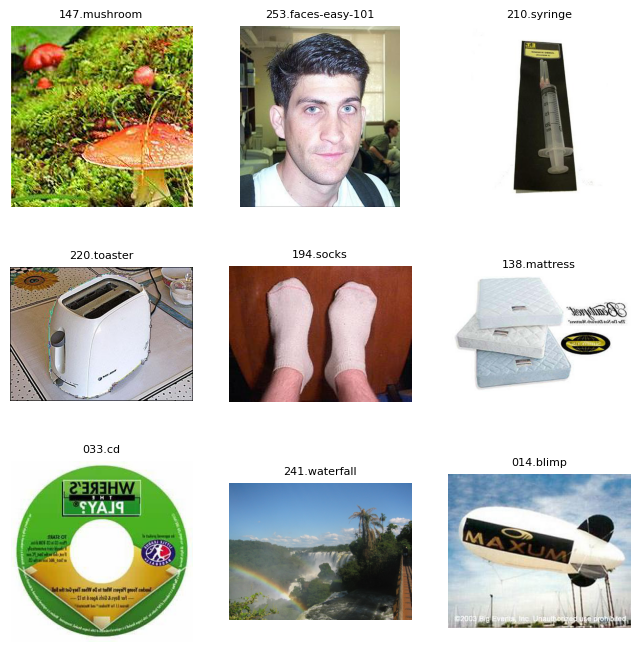

In [22]:
#Sample images
import matplotlib.pyplot as plt
import random

sample_images = []

for cls in random.sample(classes, 9):
    cls_path = os.path.join(base_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    sample_images.append(os.path.join(cls_path, img_name))

fig, axes = plt.subplots(3, 3, figsize=(8,8))

for ax, img_path in zip(axes.flatten(), sample_images):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.split("/")[-2], fontsize=8)
    ax.axis("off")

plt.show()

In [23]:
#Class Distribution
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

print("Top 5 Classes:")
for cls, count in sorted_classes[:5]:
    print(cls, count)

print("\nBottom 5 Classes:")
for cls, count in sorted_classes[-5:]:
    print(cls, count)

Top 5 Classes:
257.clutter 827
251.airplanes-101 800
145.motorbikes-101 798
253.faces-easy-101 435
232.t-shirt 358

Bottom 5 Classes:
086.golden-gate-bridge 80
099.harpsichord 80
179.scorpion-101 80
204.sunflower-101 80
223.top-hat 80


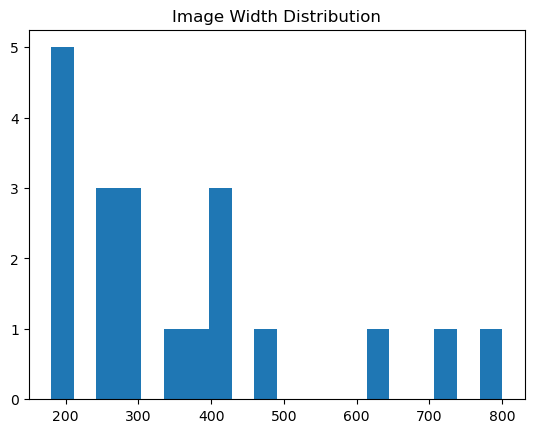

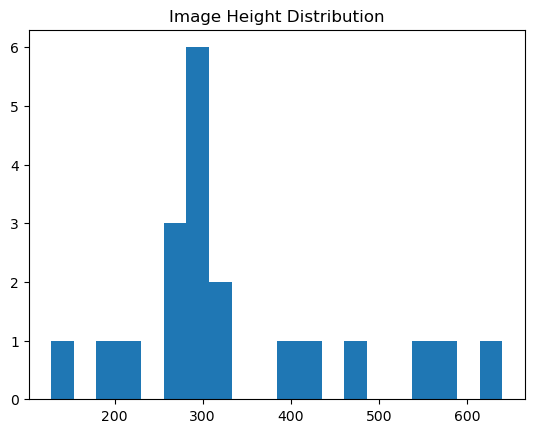

In [24]:
#Image dimensions
widths = []
heights = []

import random

sample_paths = []

for cls in random.sample(classes, 20):
    cls_path = os.path.join(base_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    sample_paths.append(os.path.join(cls_path, img_name))

for path in sample_paths:
    img = plt.imread(path)
    heights.append(img.shape[0])
    widths.append(img.shape[1])

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

## Data Preprocessing

In [25]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root="./dataset/256_ObjectCategories")

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_indices, test_indices = random_split(range(len(full_dataset)), [train_size, test_size])

train_data = Subset(
    datasets.ImageFolder(root="./dataset/256_ObjectCategories", transform=train_transform),
    train_indices.indices
)

test_data = Subset(
    datasets.ImageFolder(root="./dataset/256_ObjectCategories", transform=test_transform),
    test_indices.indices
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=32, num_workers=0)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 24485
Test size: 6122


## Training

In [26]:
#Load Not Pretrained Model
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = models.resnet50(weights=None)

# Modify final layer
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("Model ready with", num_classes, "classes")

Model ready with 257 classes


In [27]:
#Training setup
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [28]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [29]:
#Training loop
epochs = 8

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Acc: {acc:.2f}%")

Epoch 1, Loss: 5.0994, Acc: 10.65%
Epoch 2, Loss: 4.4726, Acc: 14.00%
Epoch 3, Loss: 4.0424, Acc: 20.91%
Epoch 4, Loss: 3.6743, Acc: 22.57%
Epoch 5, Loss: 3.3145, Acc: 28.24%
Epoch 6, Loss: 2.9878, Acc: 31.54%
Epoch 7, Loss: 2.7318, Acc: 35.22%
Epoch 8, Loss: 2.4629, Acc: 37.44%


## Model Evaluation

In [30]:
#Test accuracy
all_preds = []
all_labels = []

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", 100 * correct / total, "%")

Accuracy: 37.43874550800392 %


In [32]:
#Precision, Recall, F-1 Score
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.43      0.44      0.44        27
           1       0.41      0.50      0.45        18
           2       0.91      0.36      0.51        28
           3       0.35      0.28      0.31        25
           4       0.47      0.50      0.48        30
           5       0.09      0.11      0.10        18
           6       0.00      0.00      0.00        17
           7       0.36      0.26      0.30        46
           8       0.00      0.00      0.00        21
           9       0.67      0.10      0.17        21
          10       0.72      0.53      0.61        62
          11       0.39      0.69      0.50        36
          12       0.21      0.32      0.25        19
          13       1.00      0.13      0.24        15
          14       0.62      0.71      0.67        21
          15       0.75      0.14      0.24        21
          16       0.11      0.13      0.12        23
          17       0.54    

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


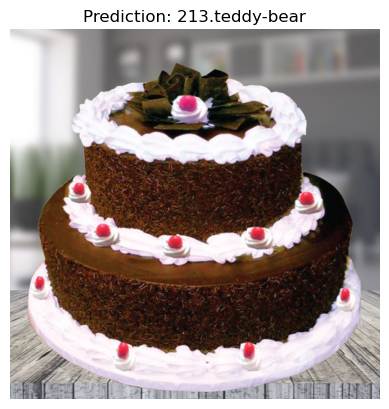

In [33]:
#Mini Google Lens
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    class_name = full_dataset.classes[predicted.item()]

    plt.imshow(img)
    plt.title(f"Prediction: {class_name}")
    plt.axis("off")
    plt.show()


predict_image("cake.jpg")

## Training Pretrained Model

In [34]:
#Load pretained model (transfer learning)
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Modify final layer
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("Model ready with", num_classes, "classes")

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready with 257 classes


In [35]:
#Training setup
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [36]:
#Training loop
epochs = 8

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Acc: {acc:.2f}%")

Epoch 1, Loss: 2.3992, Acc: 58.05%
Epoch 2, Loss: 1.2976, Acc: 66.20%
Epoch 3, Loss: 0.9285, Acc: 66.84%
Epoch 4, Loss: 0.7208, Acc: 67.79%
Epoch 5, Loss: 0.5783, Acc: 69.94%
Epoch 6, Loss: 0.4601, Acc: 69.76%
Epoch 7, Loss: 0.3976, Acc: 71.71%
Epoch 8, Loss: 0.3316, Acc: 70.48%


## Model Evaluation

In [37]:
#Test accuracy
all_preds = []
all_labels = []

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", 100 * correct / total, "%")

Accuracy: 70.48350212348906 %


In [48]:
#Precision, Recall, F-1 Score
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, output_dict=True)

f1_scores = {}
for key in report:
    if key not in ['accuracy', 'macro avg', 'weighted avg']:
        f1_scores[key] = report[key]['f1-score']

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.95      0.74      0.83        27
           1       0.68      0.94      0.79        18
           2       1.00      0.64      0.78        28
           3       0.38      0.56      0.45        25
           4       1.00      0.70      0.82        30
           5       0.92      0.61      0.73        18
           6       0.42      0.76      0.54        17
           7       0.81      0.83      0.82        46
           8       0.89      0.38      0.53        21
           9       1.00      0.24      0.38        21
          10       0.85      0.90      0.88        62
          11       0.90      0.75      0.82        36
          12       0.59      0.68      0.63        19
          13       0.83      0.33      0.48        15
          14       0.89      0.81      0.85        21
          15       0.68      0.81      0.74        21
          16       0.27      0.65      0.38        23
          17       0.58    

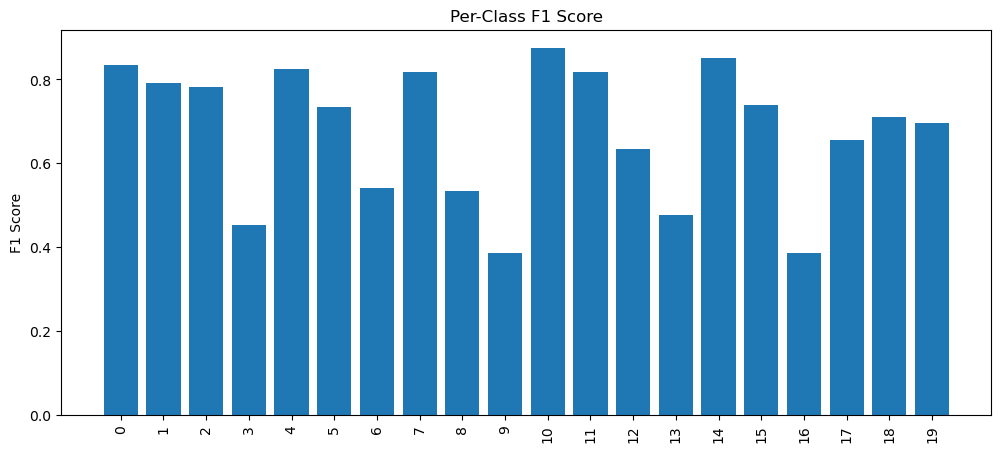

In [49]:
classes = list(f1_scores.keys())
scores = list(f1_scores.values())

plt.figure(figsize=(12,5))
plt.bar(classes[:20], scores[:20])
plt.xticks(rotation=90)
plt.title("Per-Class F1 Score")
plt.ylabel("F1 Score")
plt.show()

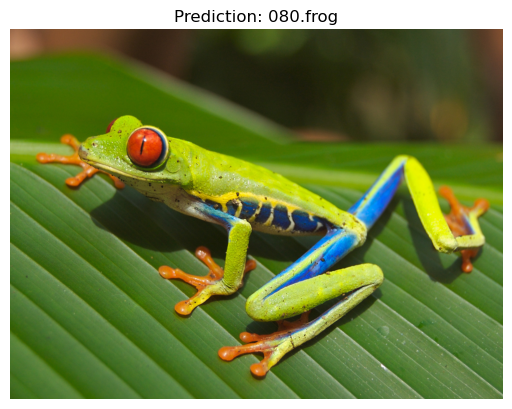

In [44]:
#Mini Google Lense
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    class_name = full_dataset.classes[predicted.item()]

    plt.imshow(img)
    plt.title(f"Prediction: {class_name}")
    plt.axis("off")
    plt.show()


predict_image("frog.jpg")

## Saving the model

In [11]:
torch.save(model.state_dict(), "model.pth")
print("Model saved!")

Model saved!
